In [19]:
!pip uninstall torch torchvision torchaudio


^C


In [20]:
! pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [19]:
import torch
from torchvision.models import mobilenet_v2
from torchvision import transforms
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


Using: cuda


In [4]:
!pip install pycocotools


In [5]:
!pip install tensorflow  torch  torchvision  torchaudio  pytorch-lightning   opencv-python  scikit-learn  matplotlib   seaborn

In [20]:
from pycocotools.coco import COCO

ann_path = "D:/mISC/Team chocos/Codes/PoliceUniDetect/DangePolice_coco/annotations/instances_train2017_clean.json"
img_dir = "D:/mISC/Team chocos/Codes/PoliceUniDetect/DangePolice_coco/train2017"

coco = COCO(ann_path)


loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


In [21]:
categories = coco.loadCats(coco.getCatIds())
class_names = [cat['name'] for cat in categories]
print("Classes:", class_names)


Classes: ['NonViolence', 'Violence', 'guns', 'knife', 'police']


In [22]:
# Define your 5 custom class names
custom_classes = ['NonViolence', 'Violence', 'guns', 'knife', 'police']

# Create a mapping from COCO category_id to your 0-indexed labels
categories = coco.loadCats(coco.getCatIds())
category_id_map = {}
for i, cat in enumerate(categories):
    if cat['name'] in custom_classes:
        category_id_map[cat['id']] = custom_classes.index(cat['name'])

print("Category ID to Class Index Map:", category_id_map)


Category ID to Class Index Map: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


In [23]:
import os

img_ids = coco.getImgIds()
data = []

for img_id in img_ids[:100]:  # You can increase the range later
    img_info = coco.loadImgs(img_id)[0]
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    # Map valid category_id to class index
    labels = [category_id_map[ann['category_id']] for ann in anns if ann['category_id'] in category_id_map]

    if len(labels) > 0:  # Only keep images with valid classes
        data.append({
            "file_name": os.path.join(img_dir, img_info['file_name']),
            "labels": labels
        })

print(data[0])  # Preview


{'file_name': 'D:/mISC/Team chocos/Codes/PoliceUniDetect/DangePolice_coco/train2017\\V_198_F81_jpg.rf.ab56c2ed366e391029df560a41cab83c.jpg', 'labels': [1]}


In [24]:
import os
import shutil
import cv2
import math
import random
import numpy as np
import datetime as dt
import tensorflow 
import keras
from collections import deque
import matplotlib.pyplot as plt
# plt.style.use("seaborn")

%matplotlib inline
 
from sklearn.model_selection import train_test_split
 
from keras.layers import *
from keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from tensorflow.keras.utils import plot_model

In [26]:

IMAGE_HEIGHT , IMAGE_WIDTH = 640, 640
 

SEQUENCE_LENGTH = 16
 

# DATASET_DIR = "../input/real-life-violence-situations-dataset/Real Life Violence Dataset/"
 
CLASSES_LIST =['NonViolence', 'Violence', 'guns', 'knife', 'police']

In [27]:
custom_classes = ['NonViolence', 'Violence', 'guns', 'knife', 'police']
class_name_to_idx = {name: i for i, name in enumerate(custom_classes)}


In [28]:
#train list

from pycocotools.coco import COCO
import os

# Paths
ann_file = "D:/mISC/Team chocos/Codes/PoliceUniDetect/DangePolice_coco/annotations/instances_train2017_clean.json"
img_dir = "D:/mISC/Team chocos/Codes/PoliceUniDetect/DangePolice_coco/train2017"

# Load COCO
coco = COCO(ann_file)

# Get all image IDs
img_ids = coco.getImgIds()

# Get categories
cats = coco.loadCats(coco.getCatIds())
cat_id_to_index = {cat['id']: idx for idx, cat in enumerate(cats)}  # COCO ID → 0-4 index

print("Classes:", [cat['name'] for cat in cats])
print("Category ID to Class Index Map:", cat_id_to_index)

# Create data list
data_list = []

for img_id in img_ids:
    img_info = coco.loadImgs(img_id)[0]
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    # Skip if no category_id
    if not anns:
        continue

    # Collect all category indices (e.g. [1, 2])
    labels = [cat_id_to_index[ann['category_id']] for ann in anns if 'category_id' in ann]

    # Optionally reduce to one label (if single-label)
    label = labels[0]  # Choose first (or use most frequent, or max conf, etc.)

    data_list.append({
        "file_name": os.path.join(img_dir, img_info['file_name']),
        "labels": label  # Use label for single-class classification
    })

# Preview
print("Example entry:", data_list[0])


loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Classes: ['NonViolence', 'Violence', 'guns', 'knife', 'police']
Category ID to Class Index Map: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}
Example entry: {'file_name': 'D:/mISC/Team chocos/Codes/PoliceUniDetect/DangePolice_coco/train2017\\V_198_F81_jpg.rf.ab56c2ed366e391029df560a41cab83c.jpg', 'labels': 1}


In [30]:
#Val data list

# COCO paths for val
val_ann_file = "D:/mISC/Team chocos/Codes/PoliceUniDetect/DangePolice_coco/annotations/instances_val2017.json"
val_img_dir = "D:/mISC/Team chocos/Codes/PoliceUniDetect/DangePolice_coco/val2017"

coco_val = COCO(val_ann_file)

val_img_ids = coco_val.getImgIds()

data_list_val = []

for img_id in val_img_ids:
    img_info = coco_val.loadImgs(img_id)[0]
    ann_ids = coco_val.getAnnIds(imgIds=img_id)
    anns = coco_val.loadAnns(ann_ids)

    if not anns:
        continue

    # Same mapping as used before
    labels = [cat_id_to_index[ann['category_id']] for ann in anns if 'category_id' in ann]
    label = labels[0]  # Use single-label classification assumption

    data_list_val.append({
        "file_name": os.path.join(val_img_dir, img_info['file_name']),
        "labels": label
    })

print("Validation sample:", data_list_val[0])


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Validation sample: {'file_name': 'D:/mISC/Team chocos/Codes/PoliceUniDetect/DangePolice_coco/val2017\\V_753_F60_jpg.rf.7cf128c88b82cb0fd83d923c149ed2ab.jpg', 'labels': 1}


In [37]:
np.save("features_test.npy", features_test)
np.save("labels_test.npy", labels_test)
np.save("file_paths_test.npy", file_paths_test)

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [33]:
from pycocotools.coco import COCO
import os

def load_coco_data(img_dir, ann_file, custom_classes):
    coco = COCO(ann_file)

    # Map COCO category_id to your 5-class index
    coco_cat_to_custom_idx = {}
    for cat in coco.loadCats(coco.getCatIds()):
        if cat['name'] in custom_classes:
            coco_cat_to_custom_idx[cat['id']] = class_name_to_idx[cat['name']]

    data_list = []

    for img_id in coco.getImgIds():
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, img_info['file_name'])

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        # One-hot multi-label
        label_vector = [0] * len(cats)
        for ann in anns:
            idx = cat_id_to_index[ann['category_id']]
            label_vector[idx] = 1

        data_list.append({
            "file_name": os.path.join(img_dir, img_info['file_name']),
            "labels": label_vector  # One-hot vector
        })


    return data_list


In [34]:
def extract_features(img_path, model, transform):
    image = Image.open(img_path).convert('RGB')
    image = transform(image).unsqueeze(0)  # [1, 3, H, W]
    with torch.no_grad():
        features = model(image.to(device)).squeeze(0).cuda()  # [feat_dim]
    return features


In [35]:
def create_dataset(data_list, cnn_model, transform):
    all_features = []
    all_labels = []
    all_paths = []

    for entry in data_list:
        try:
            feat = extract_features(entry["file_name"], cnn_model, transform)
            all_features.append(feat)
            all_labels.append(torch.tensor(entry["labels"], dtype=torch.float))  # multi-label
            all_paths.append(entry["file_name"])
        except Exception as e:
            print(f"Error loading {entry['file_name']}: {e}")
            continue

    return torch.stack(all_features), torch.stack(all_labels), all_paths


In [36]:
# Extract validation features
features_test, labels_test, file_paths_test = create_dataset(data_list_val, backbone, transform)


In [38]:
# Load pretrained MobileNetV2 and extract features
backbone = mobilenet_v2(pretrained=True).features.eval().to(device)

# Image transform (resize, normalize to ImageNet stats)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


c:\Users\Harshada\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Harshada\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [39]:
from PIL import Image
from tqdm import tqdm

def create_dataset(data_list, backbone, transform):
    features, labels, file_paths = [], [], []

    for item in tqdm(data_list):
        try:
            img = Image.open(item['file_name']).convert("RGB")
            img = transform(img).unsqueeze(0).to(device)

            with torch.no_grad():
                feat = backbone(img)
                feat = feat.mean([2, 3])  # Global average pooling [B, C, H, W] -> [B, C]

            features.append(feat.squeeze(0).cpu().numpy())
            labels.append(item['labels'])  # Can be index or one-hot
            file_paths.append(item['file_name'])

        except Exception as e:
            print(f"⚠️ Skipping {item['file_name']} due to error: {e}")

    return np.array(features), np.array(labels), file_paths


In [40]:
features, labels, video_files_paths = create_dataset(data_list, backbone, transform)


100%|██████████| 8566/8566 [01:19<00:00, 107.38it/s]


In [41]:
for i, l in enumerate(labels):
    print(f"Label {i}: {l}")


Label 0: 1
Label 1: 2
Label 2: 2
Label 3: 2
Label 4: 2
Label 5: 1
Label 6: 1
Label 7: 1
Label 8: 1
Label 9: 2
Label 10: 2
Label 11: 2
Label 12: 2
Label 13: 2
Label 14: 1
Label 15: 3
Label 16: 1
Label 17: 1
Label 18: 2
Label 19: 2
Label 20: 2
Label 21: 3
Label 22: 2
Label 23: 2
Label 24: 2
Label 25: 2
Label 26: 2
Label 27: 2
Label 28: 2
Label 29: 2
Label 30: 2
Label 31: 2
Label 32: 3
Label 33: 2
Label 34: 1
Label 35: 2
Label 36: 1
Label 37: 2
Label 38: 2
Label 39: 2
Label 40: 2
Label 41: 2
Label 42: 2
Label 43: 2
Label 44: 2
Label 45: 2
Label 46: 2
Label 47: 4
Label 48: 2
Label 49: 2
Label 50: 1
Label 51: 2
Label 52: 3
Label 53: 1
Label 54: 1
Label 55: 2
Label 56: 2
Label 57: 2
Label 58: 3
Label 59: 3
Label 60: 2
Label 61: 2
Label 62: 2
Label 63: 2
Label 64: 2
Label 65: 3
Label 66: 2
Label 67: 1
Label 68: 2
Label 69: 4
Label 70: 2
Label 71: 2
Label 72: 1
Label 73: 2
Label 74: 2
Label 75: 2
Label 76: 2
Label 77: 1
Label 78: 1
Label 79: 2
Label 80: 2
Label 81: 2
Label 82: 2
Label 83: 2
La

In [42]:
import numpy as np

# Convert integer labels to numpy array (if not already)
labels = np.array(labels)

# Number of classes
num_classes = 5

# One-hot encode
labels_one_hot = np.eye(num_classes)[labels]

# Final shape check
print("Shape of one-hot encoded labels:", labels_one_hot.shape)  # (N, 5)


Shape of one-hot encoded labels: (8566, 5)


In [43]:
np.save("labels.npy", labels_one_hot)


In [44]:
from tensorflow.keras.utils import to_categorical
import numpy as np

# If `labels` is a flat array like [1, 2, 0, 3, ...]
labels = np.array(labels)  # ensure it's an array
num_classes = 5  # for your 5 classes: NonViolence, Violence, guns, knife, police
labels = to_categorical(labels, num_classes=num_classes)



In [45]:
np.save("features.npy", features)
np.save("labels.npy", labels)
np.save("image_file_paths.npy", video_files_paths)

In [46]:
features, labels, video_files_paths = np.load("features.npy") , np.load("labels.npy") ,  np.load("image_file_paths.npy")

In [47]:
# convert labels into one-hot-encoded vectors
one_hot_encoded_labels = to_categorical(labels)

In [48]:
from keras.applications.mobilenet_v2 import MobileNetV2

mobilenet = MobileNetV2( include_top=False , weights="imagenet")

#Fine-Tuning to make the last 40 layer trainable
mobilenet.trainable=True

for layer in mobilenet.layers[:-40]:
  layer.trainable=False

#mobilenet.summary()

C:\Users\Harshada\AppData\Local\Temp\ipykernel_34824\704125511.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2( include_top=False , weights="imagenet")


In [49]:
def create_model():
 
    model = Sequential()


    
    #Specifying Input to match features shape
    model.add(Input(shape = (SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))
    

    model.add(TimeDistributed(mobilenet))
    
    model.add(Dropout(0.25))
                                    
    model.add(TimeDistributed(Flatten()))

    
    lstm_fw = LSTM(units=32)
    lstm_bw = LSTM(units=32, go_backwards = True)  

    model.add(Bidirectional(lstm_fw, backward_layer = lstm_bw))
    
    model.add(Dropout(0.25))

    model.add(Dense(256,activation='relu'))
    model.add(Dropout(0.25))

    model.add(Dense(128,activation='relu'))
    model.add(Dropout(0.25))

    model.add(Dense(64,activation='relu'))
    model.add(Dropout(0.25))

    model.add(Dense(32,activation='relu'))
    model.add(Dropout(0.25))
    
    
    model.add(Dense(len(CLASSES_LIST), activation = 'softmax'))
 

 
    model.summary()
    
    return model

In [50]:
# Constructing the Model
MoBiLSTM_model = create_model()



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 16, 20, 20,     │     2,257,984 │
│ (TimeDistributed)               │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 20, 20,     │             0 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 512000)     │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │   131,080,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,398,469 (508.87 MB)

 Trainable params: 132,822,021 (506.68 MB)

 Non-trainable params: 576,448 (2.20 MB)

In [51]:
import numpy as np

features = np.array(features)
labels = np.array(labels)


In [52]:
from keras.models import Sequential
from keras.layers import Dense, Dropout

# Create a CNN classifier on top of extracted MobileNet features
model = Sequential([
    Dense(512, activation='relu', input_shape=(1280,)),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(5, activation='softmax')  # 5 classes
])


c:\Users\Harshada\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [18]:
model.fit(
    x=features,         # shape (N, 1280)
    y=labels_one_hot,   # shape (N, 5)
    batch_size=32,
    epochs=30,
    validation_split=0.2,
    shuffle=True
)


NameError: name 'features' is not defined

In [67]:
features_test = np.load("features_test.npy")         # shape: (N_test, 1280)
labels_test = np.load("labels_test.npy")             # shape: (N_test,)

# One-hot encode labels if not already done
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
labels_test_one_hot = encoder.fit_transform(labels_test.reshape(-1, 1))


In [68]:
loss, accuracy = model.evaluate(features_test, labels_test_one_hot, batch_size=32)
print("✅ Test Accuracy:", round(accuracy * 100, 2), "%")
print("✅ Test Loss:", round(loss, 4))


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8750 - loss: 0.5978 
✅ Test Accuracy: 89.07 %
✅ Test Loss: 0.4882


In [69]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get class predictions
pred_probs = model.predict(features_test)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = np.argmax(labels_test_one_hot, axis=1)

# Print report
print("📊 Classification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=["NonViolence", "Violence", "guns", "knife", "police"]))


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
📊 Classification Report:

              precision    recall  f1-score   support

 NonViolence       0.82      0.72      0.77       189
    Violence       0.85      0.91      0.88       352
        guns       1.00      0.99      0.99       214
       knife       0.89      0.96      0.92        49
      police       0.98      0.87      0.92        47

    accuracy                           0.89       851
   macro avg       0.91      0.89      0.90       851
weighted avg       0.89      0.89      0.89       851



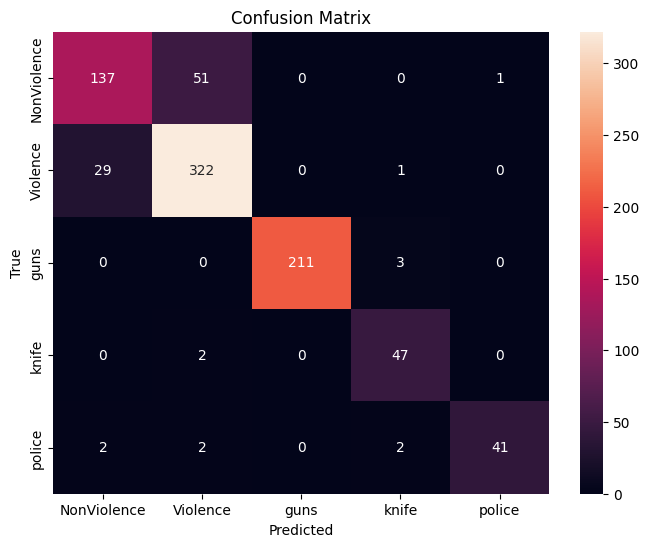

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=["NonViolence", "Violence", "guns", "knife", "police"], yticklabels=["NonViolence", "Violence", "guns", "knife", "police"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [117]:
# Save architecture and weights together
model.save("policeOrDanger.h5")




In [3]:
from keras.models import load_model

# Option A: Load full model directly
model = load_model("policeOrDanger.h5")


In [4]:
print(model.input_shape)


(None, 1280)


In [5]:
model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_47 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,743 (3.13 MB)

 Trainable params: 820,741 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

c:\Users\Harshada\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Harshada\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


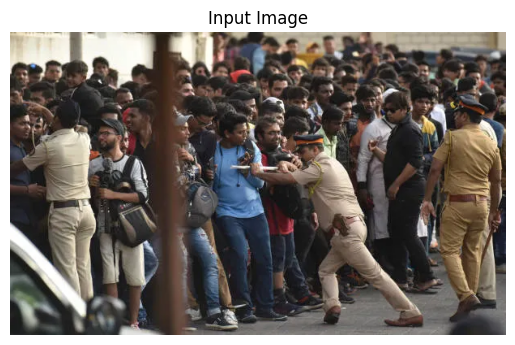

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
✅ Predicted: police
📈 Confidence: 0.9653


In [1]:
from torchvision.models import mobilenet_v2
from torchvision import transforms
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# Load trained classifier
model = load_model("policeOrDanger.h5")

# Class names
class_names = ["NonViolence", "Violence", "guns", "knife", "police"]

# Device for PyTorch backbone
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load MobileNetV2 backbone
backbone = mobilenet_v2(pretrained=True).features.eval().to(device)

# Image transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# --- 🧪 Predict Image ---
def predict_sample_image(image_path, model, backbone, transform):
    image = Image.open(image_path).convert("RGB")

    # Show image
    plt.imshow(image)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    # Preprocess for backbone
    tensor = transform(image).unsqueeze(0).to(device)  # Shape: (1, 3, 224, 224)

    # Extract 1280-dim features
    with torch.no_grad():
        feature_map = backbone(tensor)  # (1, 1280, 2, 2)
        pooled = torch.nn.functional.adaptive_avg_pool2d(feature_map, (1, 1))  # (1, 1280, 1, 1)
        feature = pooled.view(1, -1).cpu().numpy()  # (1, 1280)

    # Predict using Keras classifier
    preds = model.predict(feature)
    predicted_class = np.argmax(preds)
    confidence = np.max(preds)

    print(f"✅ Predicted: {class_names[predicted_class]}")
    print(f"📈 Confidence: {confidence:.4f}")

# --- 🔍 Usage ---
image_path = r"D:\\mISC\\Team chocos\\Codes\\sampleTestingImages\\ploce in crowd.webp"
predict_sample_image(image_path, model, backbone, transform)
